# 02: 高解像度動画 → 一次元輝度分布・スナップショット（251208系）

251208の高解像度動画（単一チャンバー撮影）から、Fig.1C/F・Fig.4・Fig.S5用の
一次元輝度分布CSVと、Fig.2A等のスナップショットを生成する。

処理: 1秒間隔フレーム抽出（ffmpeg）→ グレースケール化 →
画像幅=40mm仮定の較正（柱ありは柱エッジで確認）→
気液界面〜底面の下から3/4高さでL(x)抽出（中心±15mm）→ CSV保存。
スナップショットは指定秒（config `snap_secs`）を0.7°回転補正付きで保存。

使い方: パス設定でRAW_VIDEO_ROOT_HRを環境に合わせ、SAMPLE_IDを選んでRun All。

## セットアップ

In [113]:
import json
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from PIL import Image, ImageOps
from IPython.display import display

In [114]:
# ============ パス設定 ============
RAW_VIDEO_ROOT_HR = Path("D:/kyoto_univ/raw_videos")   # ★要変更: {date}/ 以下に動画
FRAMES_ROOT_HR = Path("D:/kyoto_univ/tempdata/frames_highres")                  # 一時フレーム（git管理外）
OUTPUT_ROOT = Path("../data/luminance_1d_highres")
SNAP_ROOT = Path("../outputs/snapshots")
CONFIG_PATH = Path("../config/samples_highres.json")

SAMPLE_ID = "251208_149A3652"                                   # ★選択

with open(CONFIG_PATH, encoding="utf-8") as f:
    config = json.load(f)
cfg = config["samples"][SAMPLE_ID]
defaults = config["defaults"]
print(json.dumps({k: cfg[k] for k in ["condition", "panels", "input_video", "snap_secs"]},
                 ensure_ascii=False, indent=2))

{
  "condition": "(1,5,1) Wp=0.5",
  "panels": "Fig4A",
  "input_video": "149A3652_fhd.mp4",
  "snap_secs": [
    900
  ]
}


## 関数群（01と共通のものはコピーを同一に保つこと）

In [115]:
def parse_sec(path: Path) -> int:
    """フレームファイル名 'frame_{sec}sec_*.png' から秒数を取り出す。"""
    return int(path.name.split("_")[1].replace("sec", ""))


def extract_frames_ffmpeg(video_path: Path, frames_dir: Path,
                          fps: int, time_period: int, start_sec: int, end_sec: int) -> None:
    """動画から time_period 秒間隔で1フレームずつPNGを抽出する（01と同一）。"""
    frames_dir.mkdir(parents=True, exist_ok=True)
    for start_time in range(start_sec, end_sec, time_period):
        output_path = frames_dir / f"frame_{start_time}sec_%2d.png"
        cmd = ["ffmpeg", "-ss", str(start_time), "-i", str(video_path),
               "-vf", f"fps={fps}", "-vframes", "1", "-vsync", "vfr", str(output_path)]
        subprocess.run(cmd, capture_output=True, text=True)


def load_grayscale_frames_hr(frames_dir: Path) -> list:
    """フレームを秒数ソートで読み込みグレースケール化（回転なし）。"""
    paths = sorted(frames_dir.glob("*.png"), key=parse_sec)
    return [ImageOps.grayscale(Image.open(p)) for p in paths]


def show_line_overlay(img, line_position, title=""):
    """画像に線分 [x1, y1, x2, y2] を重ねて表示する（01と同一）。"""
    plt.imshow(img, cmap="gray")
    plt.grid(True); plt.axis("on")
    line = mlines.Line2D([line_position[0], line_position[2]],
                         [line_position[1], line_position[3]], linewidth=2, color="r")
    plt.gca().add_line(line)
    if title: plt.title(title)


def extract_luminance_from_line(grayscale_images, line_segment):
    """水平線分 (x1, y1, x2, y2) 上の輝度値を抽出する（01と同一）。"""
    out = []
    for img in grayscale_images:
        arr = np.array(img)
        x1, y1, x2, y2 = (round(v) for v in line_segment)
        out.append(arr[y1, x1:x2 + 1].tolist())
    return out

## §1 フレーム抽出（1秒間隔）

In [116]:
video_path = RAW_VIDEO_ROOT_HR / cfg["date"] / cfg["input_video"]
frames_dir = FRAMES_ROOT_HR / SAMPLE_ID
if frames_dir.exists():
    print(f"Skip: 抽出済み -> {frames_dir}")
else:
    assert video_path.exists(), f"動画が見つかりません: {video_path}"
    extract_frames_ffmpeg(video_path, frames_dir, fps=defaults["fps"],
                          time_period=defaults["time_period_sec"],
                          start_sec=defaults["start_sec"], end_sec=defaults["end_sec"])
print(f"フレーム数: {len(list(frames_dir.glob('*.png')))}")

フレーム数: 1800


## §2 読み込み（グレースケール化・回転なし）

20枚, 1920x1080


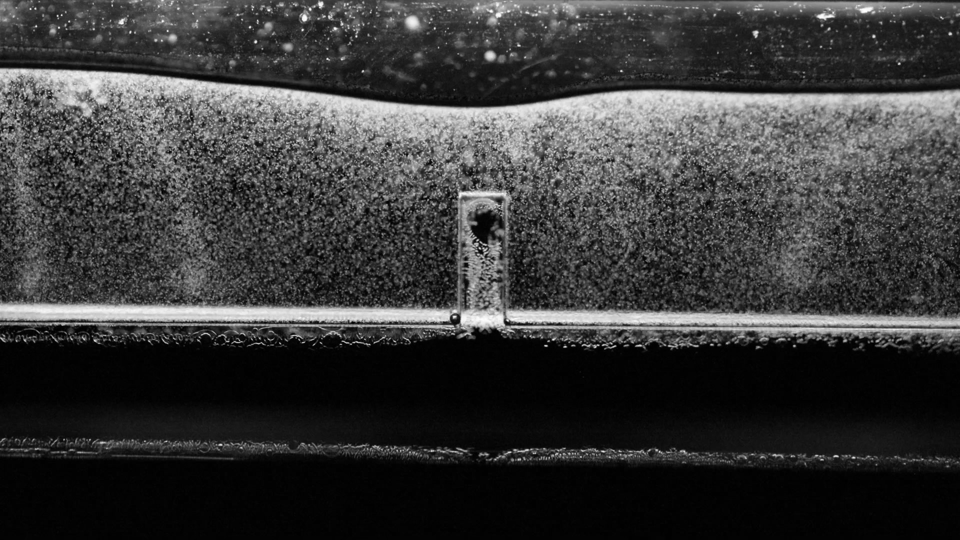

In [81]:
images = load_grayscale_frames_hr(frames_dir)
W, H = images[0].size
print(f"{len(images)}枚, {W}x{H}")
display(images[-1].resize((W//2, H//2)))

## §3 キャリブレーション確認

px/mm = 画像幅/40mm。抽出線は「底面から水深の3/4の高さ」、x範囲は中心±15mm。
柱ありサンプルは柱エッジ（config `pillar_edges_px`）の目視確認も行う。

px/mm=48.00, 界面y=170, 底面y=640, 抽出線y=288, x=240-1680
柱エッジ: [919, 1012] (幅 1.94 mm相当)


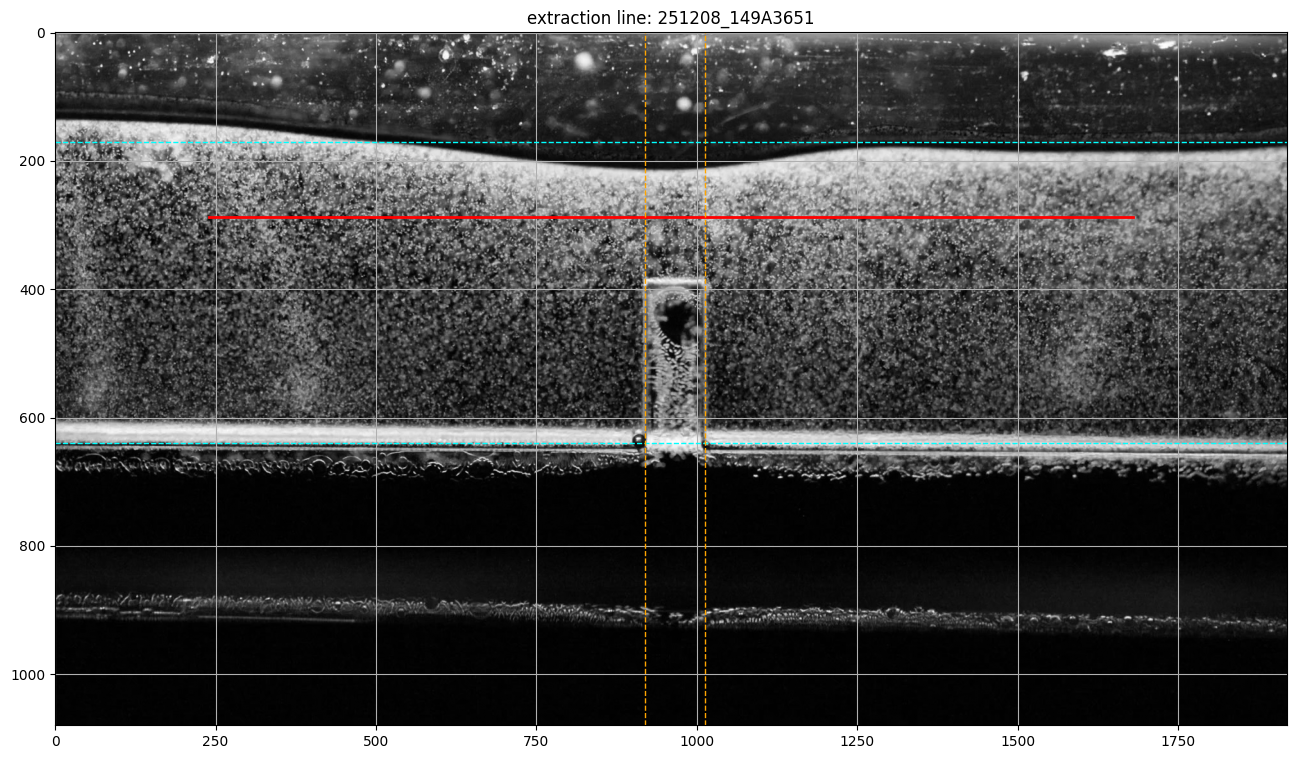

In [82]:
px_per_mm = W / defaults["image_width_mm"]
y_if, y_fl = cfg["y_interface_px"], cfg["y_floor_px"]
hr = cfg.get("height_ratio_from_floor", defaults["height_ratio_from_floor"])
line_y = round(y_fl - hr * (y_fl - y_if))
dx = round(defaults["analysis_halfwidth_mm"] * px_per_mm)
line = [W // 2 - dx, line_y, W // 2 + dx, line_y]
print(f"px/mm={px_per_mm:.2f}, 界面y={y_if}, 底面y={y_fl}, 抽出線y={line_y}, x={line[0]}-{line[2]}")

plt.figure(figsize=(16, 9))
show_line_overlay(images[-1], line, title=f"extraction line: {SAMPLE_ID}")
for yy, lab in [(y_if, "interface"), (y_fl, "floor")]:
    plt.axhline(yy, color="cyan", linestyle="--", linewidth=1)
if cfg["pillar_edges_px"]:
    for xx in cfg["pillar_edges_px"]:
        plt.axvline(xx, color="orange", linestyle="--", linewidth=1)
    pe = cfg["pillar_edges_px"]
    print(f"柱エッジ: {pe} (幅 {(pe[1]-pe[0])/px_per_mm:.2f} mm相当)")
plt.show()

## §4 一次元輝度分布の抽出・保存

In [ ]:
lumi = extract_luminance_from_line(images, line)
out_dir = OUTPUT_ROOT / cfg["date"]
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"lumi1d_hr_{cfg['date']}_{cfg['video']}.csv"
pd.DataFrame(lumi).to_csv(out_path)
print(f"{np.shape(lumi)} -> {out_path}")
print(f"(旧ファイル名: {cfg['legacy_csv']})")

## §5 スナップショット（config `snap_secs` の各秒を微小回転補正付きで保存）

In [ ]:
snap_dir = SNAP_ROOT / SAMPLE_ID
snap_dir.mkdir(parents=True, exist_ok=True)
for sec in cfg["snap_secs"]:
    p = frames_dir / f"frame_{sec}sec_ 1.png"
    if not p.exists():
        cand = [q for q in frames_dir.glob(f"frame_{sec}sec_*.png")]
        assert cand, f"フレームなし: {sec}s（time_period=1で抽出済みか確認）"
        p = cand[0]
    img = ImageOps.grayscale(Image.open(p)).rotate(cfg["fine_rotation_deg"], expand=True)
    outp = snap_dir / f"snap_{cfg['video']}_{sec}s.png"
    img.save(outp)
    print(f"saved: {outp}")

## 補足
- 旧コードからの変更: フレーム順序の数値ソート保証、座標のconfig集約、スナップショット秒の外部化
  （旧1320-1355s切り出しは論文不使用のため廃止、Fig.2A用の1567/1574/1581sをconfigに登録済み）。
- クロップ範囲は図の組版依存のため02では行わず全景を保存（必要ならIllustrator側でトリミング）。
- input_videoの `_fhd` 有無、および3644/3646の用途は要確認。